In [3]:
#   Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
#   Load Dataset
df = pd.read_csv('Advertising.csv')
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [5]:
#   Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [6]:
#   Shape of Dataset
print("Rows and Columns:", df.shape)

Rows and Columns: (200, 5)


In [31]:
#   Statistical Summary
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [7]:
#   Check Missing Values
df.isnull().sum()

,0
Unnamed: 0,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [8]:
#   Handle Missing Values (if any)
df.dropna(inplace=True)

In [9]:
#   Check Duplicate Records
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [10]:
#   Remove Duplicates
df.drop_duplicates(inplace=True)

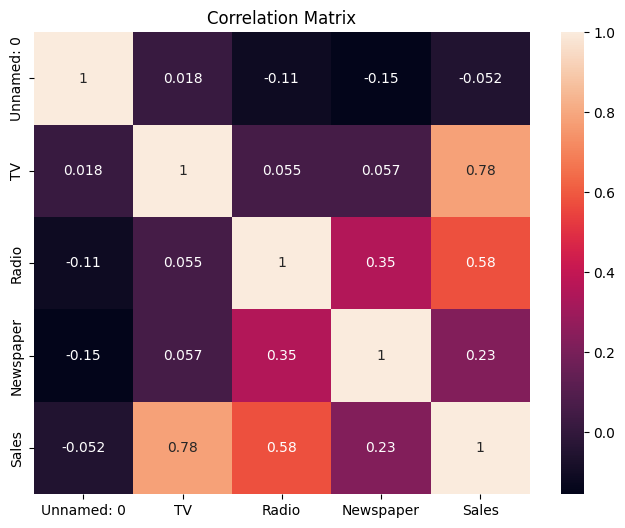

In [11]:
#   Correlation Matrix
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.savefig("correlation_matrix.png")
plt.show()

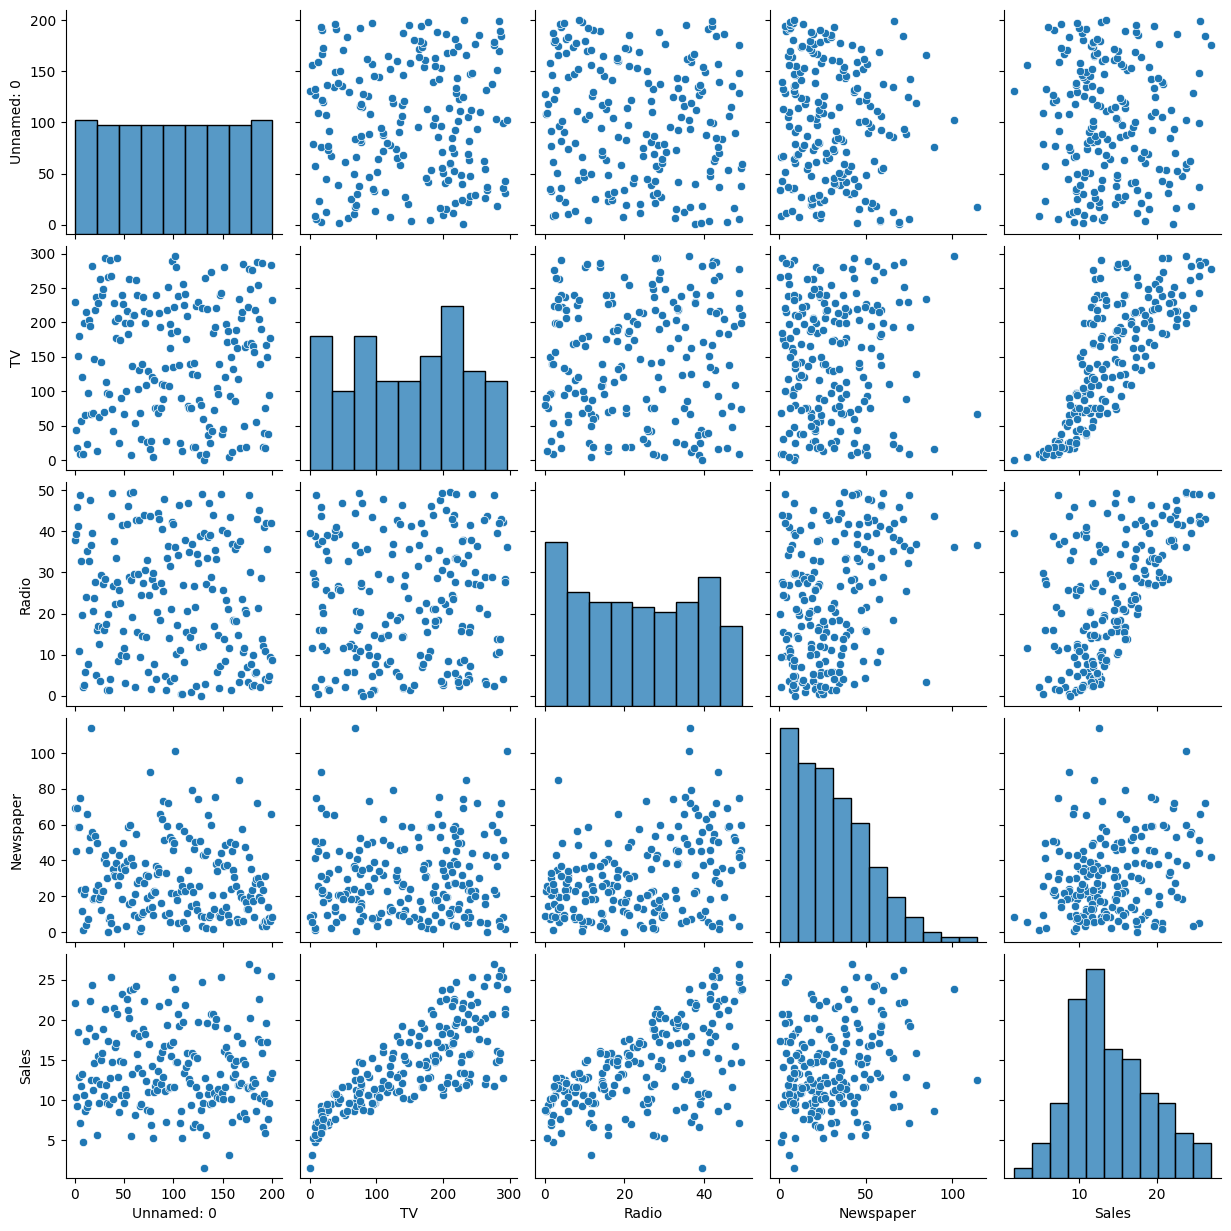

In [12]:
#   Pairplot
sns.pairplot(df)
plt.show()

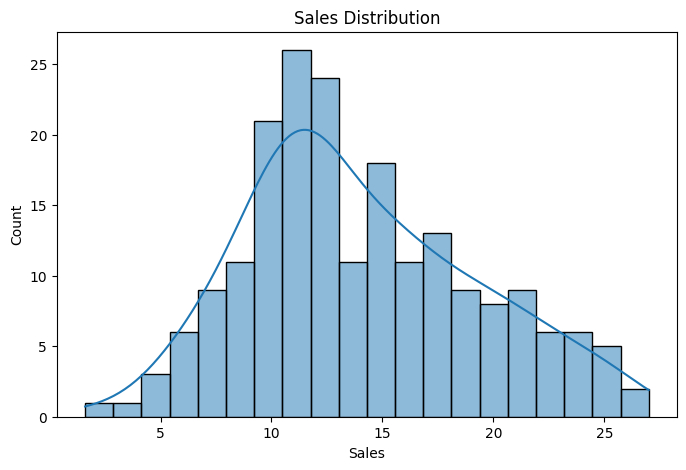

In [13]:
#   Sales Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Sales'], bins=20, kde=True)
plt.title("Sales Distribution")
plt.savefig("sales_distribution.png")
plt.show()

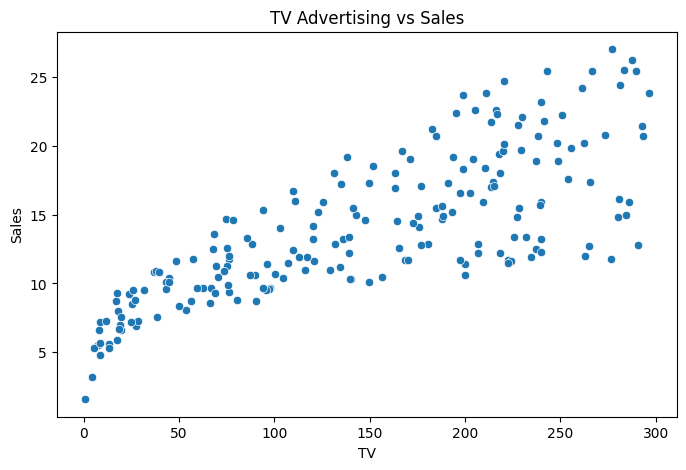

In [14]:
#   TV Advertising vs Sales
plt.figure(figsize=(8,5))
sns.scatterplot(x='TV', y='Sales', data=df)
plt.title("TV Advertising vs Sales")
plt.savefig("tv_vs_sales.png")
plt.show()

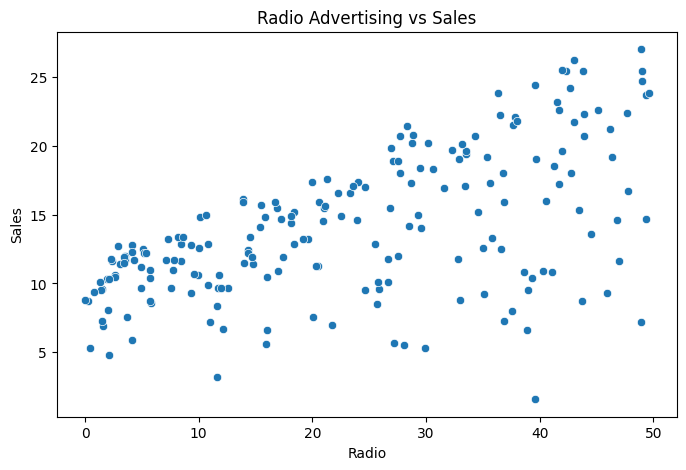

In [15]:
#   Radio Advertising vs Sales
plt.figure(figsize=(8,5))
sns.scatterplot(x='Radio', y='Sales', data=df)
plt.title("Radio Advertising vs Sales")
plt.savefig("radio_vs_sales.png")
plt.show()

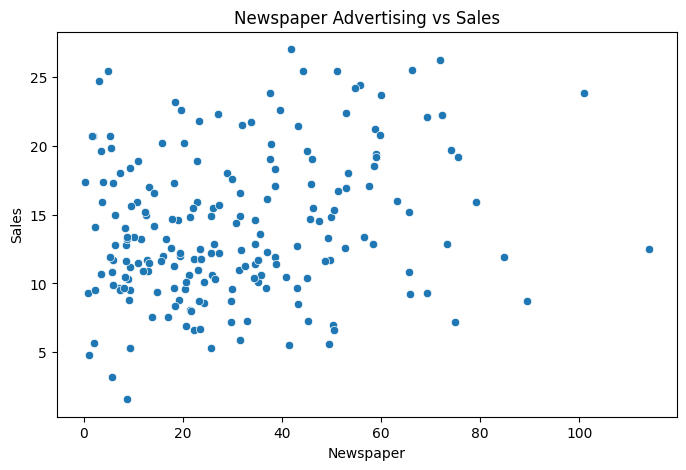

In [16]:
#   Newspaper Advertising vs Sales
plt.figure(figsize=(8,5))
sns.scatterplot(x='Newspaper', y='Sales', data=df)
plt.title("Newspaper Advertising vs Sales")
plt.savefig("newspaper_vs_sales.png")
plt.show()

In [17]:
#   Feature Selection
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

In [18]:
#   Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
#   Model Training
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [20]:
#   Model Prediction
y_pred = model.predict(X_test)

In [21]:
#   Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 1.4607567168117603


In [22]:
#   Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 3.1740973539761033


In [23]:
#    Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 1.78159966153345


In [24]:
#   R² Score
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.899438024100912


In [25]:
#   Actual vs Predicted Values
results = pd.DataFrame({
    'Actual Sales': y_test,
    'Predicted Sales': y_pred
})

results.head(10)

,Actual Sales,Predicted Sales
95,16.9,16.408024
15,22.4,20.889882
30,21.4,21.553843
158,7.3,10.608503
128,24.7,22.112373
115,12.6,13.105592
69,22.3,21.057192
170,8.4,7.461010
174,11.5,13.606346
45,14.9,15.155070


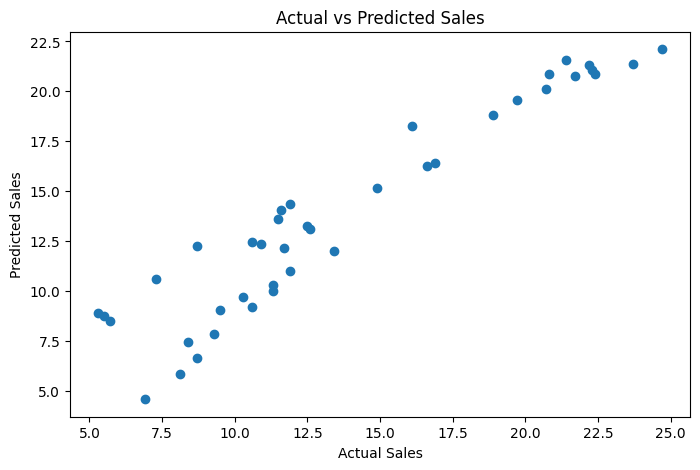

In [32]:
#   Visualization of Predictions
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.savefig("actual_vs_predicted.png")
plt.show()

In [27]:
#   Custom Prediction
tv = 230
radio = 37
newspaper = 69

prediction = model.predict([[tv, radio, newspaper]])

print("Predicted Sales:", prediction[0])

Predicted Sales: 20.45759025215365


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [28]:
#   Model Coefficients
print("TV Coefficient:", model.coef_[0])
print("Radio Coefficient:", model.coef_[1])
print("Newspaper Coefficient:", model.coef_[2])

TV Coefficient: 0.044729517468716326
Radio Coefficient: 0.18919505423437652
Newspaper Coefficient: 0.0027611143413671935


In [29]:
#   Intercept
print("Intercept:", model.intercept_)

Intercept: 2.979067338122629


In [30]:
#   Conclusion
print("Sales Prediction Model Built Successfully")
print("Model Accuracy (R² Score):", r2)

Sales Prediction Model Built Successfully
Model Accuracy (R² Score): 0.899438024100912
